# Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

# Data

In [13]:
data_train = pd.read_csv("./data/train.csv")
data_test = pd.read_csv("./data/test.csv")
sample_submission = pd.read_csv("./data/sample_submission.csv")

In [14]:
len(data_train), len(data_test)

(140700, 93800)

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

# Gender

In [7]:
data_train["Gender"]

0         Female
1           Male
2           Male
3           Male
4         Female
           ...  
140695    Female
140696    Female
140697    Female
140698    Female
140699      Male
Name: Gender, Length: 140700, dtype: object

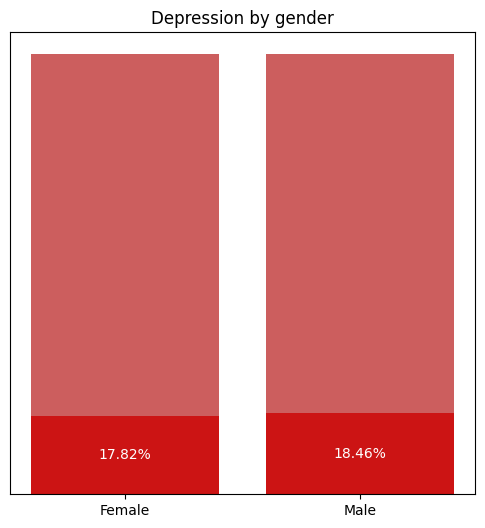

In [79]:
gender = data_train[["Gender", "Depression", "id"]].groupby(["Gender", "Depression"]).count()

plt.figure(figsize=(6, 6))
female_count = sum(gender.loc["Female"]["id"])
female_depression_rate = gender.loc["Female"].loc[1].values[0] / female_count
male_count = sum(gender.loc["Male"]["id"])
male_depression_rate = gender.loc["Male"].loc[1].values[0] / male_count
plt.bar(0, female_depression_rate, color="#cc1414")
plt.bar(0, 1 - female_depression_rate, bottom=female_depression_rate, color="#cc5e5e")
plt.text(0, female_depression_rate/2, f"{female_depression_rate*100:.2f}%", ha="center", va="center", color="white")
plt.bar(1, male_depression_rate, color="#cc1414")
plt.bar(1, 1 - male_depression_rate, bottom=male_depression_rate, color="#cc5e5e")
plt.text(1, male_depression_rate/2, f"{male_depression_rate*100:.2f}%", ha="center", va="center", color="white")
plt.axis()
plt.xticks([0, 1], ["Female", "Male"])
plt.yticks([])
plt.title("Depression by gender")
plt.show()

# Age

In [8]:
data_train.Age

0         49.0
1         26.0
2         33.0
3         22.0
4         30.0
          ... 
140695    18.0
140696    41.0
140697    24.0
140698    49.0
140699    27.0
Name: Age, Length: 140700, dtype: float64

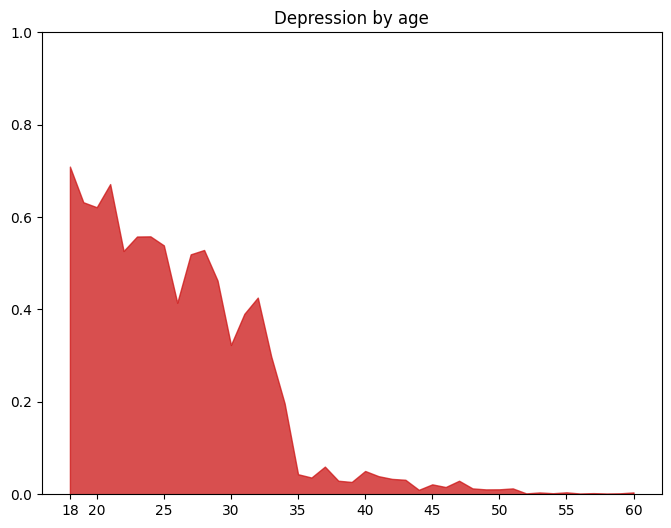

In [78]:
age = data_train[["Age", "Depression", "id"]].groupby(["Age", "Depression"]).count()
age_count = {}
age_depression_rate = {}

for (non_dep_age, _), (with_dep_age, _) in age.index.to_numpy().reshape((43, 2)):
    non_dep_count = age.loc[non_dep_age].loc[0].values[0]
    with_dep_count = age.loc[with_dep_age].loc[1].values[0]
    age_count[non_dep_age] = non_dep_count + with_dep_count
    age_depression_rate[with_dep_age] = with_dep_count / (non_dep_count + with_dep_count)

plt.figure(figsize=(8, 6))
plt.fill_between(
    age_depression_rate.keys(),
    [0]*len(age_depression_rate),
    age_depression_rate.values(),
    color="#cc1414",
    alpha=0.75
)
plt.ylim(0, 1)
plt.xticks([18]+list(range(20, 61, 5)))
plt.title("Depression by age")
plt.show()

# City

In [4]:
data_train["City"].value_counts()

City
Kalyan         6591
Patna          5924
Vasai-Virar    5765
Kolkata        5689
Ahmedabad      5613
               ... 
Shrey             1
Ivaan             1
Vaanya            1
Gaurav            1
Unirar            1
Name: count, Length: 98, dtype: int64

In [3]:
cities = data_train.City.unique()
df = []
for city in cities:
    city_count = len(data_train[data_train["City"] == city])
    city_dep_count = len(data_train[(data_train["City"] == city) & (data_train["Depression"] == 1)])
    df.append([city, city_count, city_dep_count])

df = pd.DataFrame(df)
df.columns = ["City", "Count", "Depression count"]
df["Depression rate"] = df["Depression count"] / df["Count"]
df = df[df["Count"] > 10]
df.set_index("City", inplace=True)
df.sort_values("Depression rate", inplace=True)

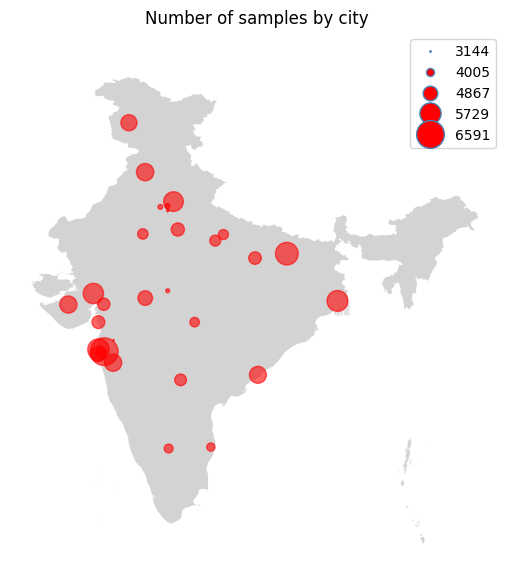

In [4]:
with open("data/geojson/cities_locations.json", "r") as f:
    cities = json.load(f)["cities"]

cities = pd.DataFrame({
    "City": cities.keys(),
    "latitude": [coords[0] for coords in cities.values()],
    "longitude": [coords[1] for coords in cities.values()]
})

cities.set_index("City", inplace=True)
cities = pd.concat([df, cities], axis=1)

geometry = [Point(xy) for xy in zip(cities['longitude'], cities['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

world = gpd.read_file("data/geojson/india.geojson")

fig, ax = plt.subplots(figsize=(7, 7))
world.plot(ax=ax, color='lightgrey')
gplt.pointplot(gdf, ax=ax, color='red', scale="Count", limits=(1, 20), alpha=0.6, legend=True, legend_var='scale')

plt.xlim(67, 99)
plt.ylim(5, 40)
plt.title("Number of samples by city")
plt.show()

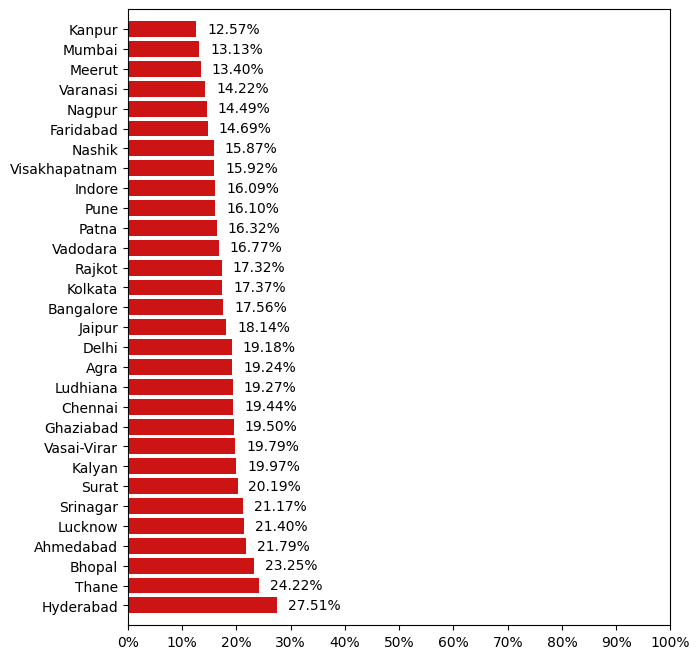

In [5]:
plt.figure(figsize=(7, 8))
for i, city in enumerate(df.index):
    plt.barh(len(df)-i-1, df.loc[city]["Depression rate"], color="#cc1414")
    plt.text(df.loc[city]["Depression rate"] + 0.02, len(df)-i-1, f"{df.loc[city]["Depression rate"]*100:.2f}%", va="center")
plt.xlim(0, 1)
plt.ylim(-1, len(df))
plt.xticks(np.arange(0, 1.1, 0.1), [f"{v}%" for v in np.arange(0, 110, 10)])
plt.yticks(np.arange(len(df)), reversed(df.index))
plt.show()

# Working Professional (Profession, Work Pressure, Job Satisfaction)

In [22]:
working_professionals = data_train[data_train["Working Professional or Student"] == "Working Professional"]

In [143]:
work_pressure = working_professionals[["Work Pressure", "Depression", "id"]].groupby(["Work Pressure", "Depression"]).count()
work_pressure = work_pressure.reset_index()
pressure_count = []
pressure_dept_rates = []
for pressure in work_pressure["Work Pressure"].unique():
    pressure_non_dep_count = work_pressure[
        (work_pressure["Work Pressure"] == pressure) &
        (work_pressure["Depression"] == 0)
    ]["id"].values[0]
    pressure_dep_count = work_pressure[
        (work_pressure["Work Pressure"] == pressure) &
        (work_pressure["Depression"] == 1)
    ]["id"].values[0]
    pressure_dept_rate = pressure_dep_count / (pressure_dep_count + pressure_non_dep_count)
    pressure_dept_rates.append(pressure_dept_rate)
    pressure_count.append(pressure_dep_count + pressure_non_dep_count)
work_pressure = pd.DataFrame({
    "Work Pressure": work_pressure["Work Pressure"].unique(),
    "Depression rate": pressure_dept_rates,
    "Count": pressure_count
})
work_pressure["Depression rate"] *= 100
work_pressure

,Work Pressure,Depression rate,Count
0,1.0,2.249328,21562
1,2.0,3.229115,24372
2,3.0,5.438605,21899
3,4.0,10.478856,22512
4,5.0,19.608630,22434


In [148]:
job_satisfaction = working_professionals[["Job Satisfaction", "Depression", "id"]].groupby(["Job Satisfaction", "Depression"]).count()
job_satisfaction = job_satisfaction.reset_index()
pressure_count = []
pressure_dept_rates = []
for pressure in job_satisfaction["Job Satisfaction"].unique():
    pressure_non_dep_count = job_satisfaction[
        (job_satisfaction["Job Satisfaction"] == pressure) &
        (job_satisfaction["Depression"] == 0)
    ]["id"].values[0]
    pressure_dep_count = job_satisfaction[
        (job_satisfaction["Job Satisfaction"] == pressure) &
        (job_satisfaction["Depression"] == 1)
    ]["id"].values[0]
    pressure_dept_rate = pressure_dep_count / (pressure_dep_count + pressure_non_dep_count)
    pressure_dept_rates.append(pressure_dept_rate)
    pressure_count.append(pressure_dep_count + pressure_non_dep_count)
job_satisfaction = pd.DataFrame({
    "Job Satisfaction": job_satisfaction["Job Satisfaction"].unique(),
    "Depression rate": pressure_dept_rates,
    "Count": pressure_count
})
job_satisfaction["Depression rate"] *= 100
job_satisfaction

,Job Satisfaction,Depression rate,Count
0,1.0,17.399875,22322
1,2.0,9.826473,24780
2,3.0,5.448747,21950
3,4.0,3.939191,20918
4,5.0,3.875153,22812


# Student (Academic Pressure, CGPA, Study Satisfaction)

In [27]:
students = data_train[data_train["Working Professional or Student"] == "Student"]

In [173]:
students[["CGPA", "Depression"]].corr()

,CGPA,Depression
CGPA,1.000000,0.021829
Depression,0.021829,1.000000


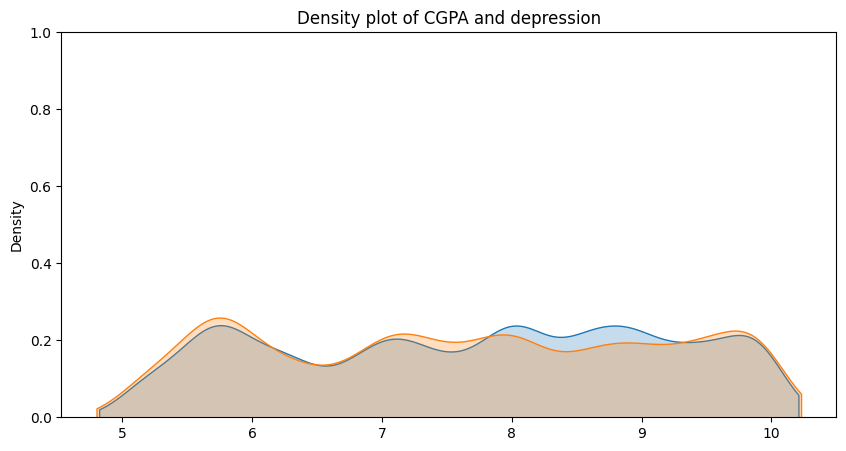

In [172]:
cgpa_dep = students[students["Depression"] == 1]["CGPA"].to_list()
cgpa_non_dep = students[students["Depression"] == 0]["CGPA"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(cgpa_dep, ax=ax, fill=True, cut=True)
sns.kdeplot(cgpa_non_dep, ax=ax, fill=True, cut=True)
ax.set_ylim(0, 1)
plt.title("Density plot of CGPA and depression")
plt.show()

# Sleep Duration

In [7]:
data_train["Sleep Duration"].value_counts()

Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
2-3 hours                5
4-6 hours                5
6-8 hours                4
1-6 hours                4
No                       4
9-11 hours               2
10-11 hours              2
Sleep_Duration           2
Unhealthy                2
45                       2
8-9 hours                2
10-6 hours               1
9-5                      1
45-48 hours              1
3-6 hours                1
Work_Study_Hours         1
49 hours                 1
than 5 hours             1
Pune                     1
9-6 hours                1
8 hours                  1
35-36 hours              1
Indore                   1
1-3 hours                1
55-66 hours              1
Moderate                 1
40-45 hours              1
1-2 hours                1
9-5 hours                1
Name: count, 

In [13]:
sleep_duration = data_train[["Sleep Duration", "id"]].groupby("Sleep Duration").count()
sleep_duration = sleep_duration[sleep_duration["id"] > 20]
sleep_duration

,id
Sleep Duration,
5-6 hours,32142
7-8 hours,36969
Less than 5 hours,38784
More than 8 hours,32726


In [190]:
valid = ["Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours"]
sleep_duration = data_train[data_train["Sleep Duration"].isin(valid)][["Sleep Duration", "Depression", "id"]]\
    .groupby(["Sleep Duration", "Depression"]).count()

sleep_duration_non_dep = sleep_duration.loc[[idx for idx in sleep_duration.index if (idx[1] == 0)]]
sleep_duration_non_dep = sleep_duration_non_dep.reset_index().drop(["Depression"], axis=1).set_index("Sleep Duration")

sleep_duration_dep = sleep_duration.loc[[idx for idx in sleep_duration.index if (idx[1] == 1)]]
sleep_duration_dep = sleep_duration_dep.reset_index().drop(["Depression"], axis=1).set_index("Sleep Duration")

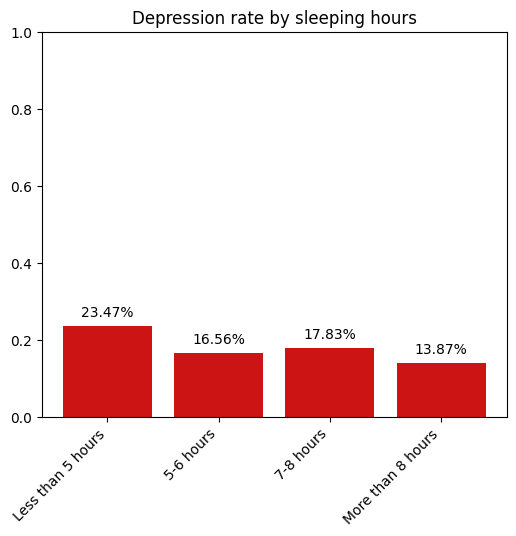

In [199]:
plt.figure(figsize=(6, 5))
for i, sleep_dur in enumerate(valid):
    slp_dur_count = sleep_duration_dep.loc[sleep_dur].values[0]
    slp_non_dur_count = sleep_duration_non_dep.loc[sleep_dur].values[0]

    slp_dur_rate = slp_dur_count / (slp_dur_count + slp_non_dur_count)

    plt.bar(i, slp_dur_rate, color="#cc1414")
    plt.text(i, slp_dur_rate + 0.025, f"{slp_dur_rate*100:.2f}%", ha="center")

plt.xticks(np.arange(4), valid, rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Depression rate by sleeping hours")
plt.show()

# Dietary Habits

In [8]:
data_train["Dietary Habits"].value_counts()

Dietary Habits
Moderate             49705
Unhealthy            46227
Healthy              44741
Yes                      2
No                       2
More Healthy             2
No Healthy               1
Class 12                 1
Indoor                   1
Male                     1
Vegas                    1
M.Tech                   1
Less Healthy             1
1.0                      1
Electrician              1
Hormonal                 1
Mihir                    1
Less than Healthy        1
3                        1
Gender                   1
BSc                      1
Pratham                  1
2                        1
Name: count, dtype: int64

In [ ]:
data_train[["Dietary Habits", "id"]].groupby("Dietary Habits").count()

valid = ["Healthy", "Moderate", "Unhealthy"]
dietary_habits = data_train[data_train["Dietary Habits"].isin(valid)]
dietary_habits = dietary_habits[["Dietary Habits", "Depression", "id"]].groupby(["Dietary Habits", "Depression"]).count()

dietary_habits_non_dep = dietary_habits.loc[[idx for idx in dietary_habits.index if (idx[1] == 0)]]
dietary_habits_non_dep = dietary_habits_non_dep.reset_index().drop(["Depression"], axis=1).set_index("Dietary Habits")

dietary_habits_dep = dietary_habits.loc[[idx for idx in dietary_habits.index if (idx[1] == 1)]]
dietary_habits_dep = dietary_habits_dep.reset_index().drop(["Depression"], axis=1).set_index("Dietary Habits")

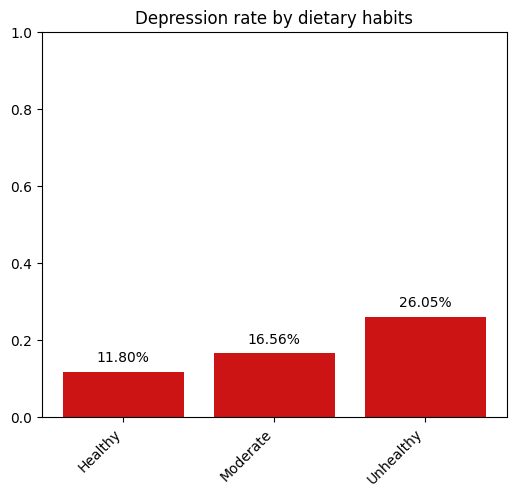

In [213]:
plt.figure(figsize=(6, 5))
for i, dietary_habit in enumerate(valid):
    dietary_habit_dep_count = dietary_habits_dep.loc[dietary_habit].values[0]
    dietary_habit_non_dep_count = dietary_habits_non_dep.loc[dietary_habit].values[0]

    dietary_habit_dep_rate = dietary_habit_dep_count / (dietary_habit_dep_count + dietary_habit_non_dep_count)

    plt.bar(i, dietary_habit_dep_rate, color="#cc1414")
    plt.text(i, dietary_habit_dep_rate + 0.025, f"{dietary_habit_dep_rate*100:.2f}%", ha="center")

plt.xticks(np.arange(len(valid)), valid, rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Depression rate by dietary habits")
plt.show()

# Degree

In [11]:
data_train["Degree"].value_counts().to_frame().tail(25)

,count
Degree,
Class 11,1
20,1
S.Tech,1
Veda,1
BH,1
MPA,1
S.Pharm,1
M. Business Analyst,1
Bhavesh,1


In [237]:
degree = data_train[["Degree", "id"]].groupby(["Degree"]).count()
degree = degree[degree["id"] > 10]

valid = degree.index.to_list()

degree = data_train[data_train["Degree"].isin(valid)]
degree = degree[["Degree", "Depression", "id"]].groupby(["Degree", "Depression"]).count()

degree_non_dep = degree.loc[[idx for idx in degree.index if (idx[1] == 0)]]
degree_non_dep = degree_non_dep.reset_index().drop(["Depression"], axis=1).set_index("Degree")

degree_dep = degree.loc[[idx for idx in degree.index if (idx[1] == 1)]]
degree_dep = degree_dep.reset_index().drop(["Depression"], axis=1).set_index("Degree")

degree = pd.concat([degree_dep, degree_non_dep], axis=1)
degree.columns = ["dep", "non_dep"]
degree["dep_rate"] = degree["dep"] / (degree["dep"] + degree["non_dep"])
degree.sort_values(["dep_rate"], inplace=True)

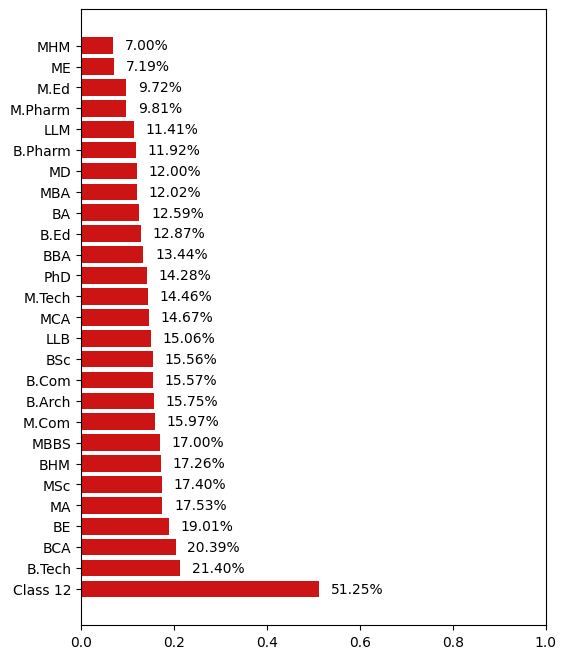

In [244]:
plt.figure(figsize=(6, 8))
for i, dep_rate in enumerate(degree["dep_rate"].to_list()):
    plt.barh(len(degree_dep)-i-1, dep_rate, color="#cc1414")
    plt.text(dep_rate + 0.025, len(degree_dep)-i-1, f"{dep_rate*100:.2f}%", va="center")

plt.xlim(0, 1)
plt.yticks(np.arange(len(degree_dep)), reversed(degree.index))
plt.show()

# Have you ever had suicidal thoughts ?

In [16]:
suicidal_thoughts = data_train[["Have you ever had suicidal thoughts ?"]]

suicidal_thoughts_yes = data_train[data_train["Have you ever had suicidal thoughts ?"] == "Yes"]
suicidal_thoughts_yes = suicidal_thoughts_yes[["Have you ever had suicidal thoughts ?", "Depression", "id"]]\
    .groupby(["Have you ever had suicidal thoughts ?", "Depression"]).count()
suicidal_thoughts_no = data_train[data_train["Have you ever had suicidal thoughts ?"] == "No"]
suicidal_thoughts_no = suicidal_thoughts_no[["Have you ever had suicidal thoughts ?", "Depression", "id"]]\
    .groupby(["Have you ever had suicidal thoughts ?", "Depression"]).count()

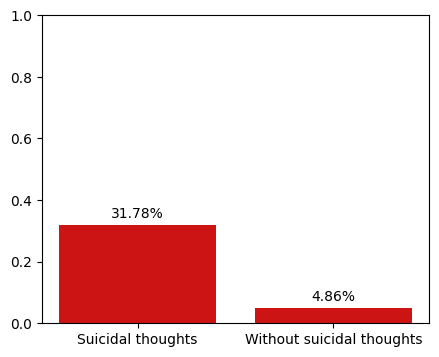

In [262]:
suicidal_thoughts_yes_dep = suicidal_thoughts_yes.loc["Yes"].loc[1]
suicidal_thoughts_yes_non_dep = suicidal_thoughts_yes.loc["Yes"].loc[0]
suicidal_thoughts_no_dep = suicidal_thoughts_no.loc["No"].loc[1]
suicidal_thoughts_no_non_dep = suicidal_thoughts_no.loc["No"].loc[0]

suicidal_thoughts_yes_dep_rate = (suicidal_thoughts_yes_dep / (suicidal_thoughts_yes_dep + suicidal_thoughts_yes_non_dep)).values[0]
suicidal_thoughts_no_dep_rate = (suicidal_thoughts_no_dep / (suicidal_thoughts_no_dep + suicidal_thoughts_no_non_dep)).values[0]

plt.figure(figsize=(5, 4))
plt.bar(0, suicidal_thoughts_yes_dep_rate, color="#cc1414")
plt.bar(1, suicidal_thoughts_no_dep_rate, color="#cc1414")
plt.text(0, suicidal_thoughts_yes_dep_rate + 0.025, f"{suicidal_thoughts_yes_dep_rate*100:.2f}%", ha="center")
plt.text(1, suicidal_thoughts_no_dep_rate + 0.025, f"{suicidal_thoughts_no_dep_rate*100:.2f}%", ha="center")
plt.xticks([0, 1], ["Suicidal thoughts", "Without suicidal thoughts"])
plt.ylim(0, 1)
plt.show()

# Work/Study Hours

In [ ]:
working_professionals_dep = working_professionals[working_professionals["Depression"] == 1][["Work/Study Hours", "id"]].groupby("Work/Study Hours").count()
working_professionals_non_dep = working_professionals[working_professionals["Depression"] == 0][["Work/Study Hours", "id"]].groupby("Work/Study Hours").count()
working_professionals_dep_rate = pd.concat([working_professionals_dep, working_professionals_non_dep], axis=1)
working_professionals_dep_rate.columns = ["dep", "non_dep"]
working_professionals_dep_rate["dep_rate"] = working_professionals_dep_rate["dep"] / (working_professionals_dep_rate["dep"] + working_professionals_dep_rate["non_dep"])

students_dep = students[students["Depression"] == 1][["Work/Study Hours", "id"]].groupby("Work/Study Hours").count()
students_non_dep = students[students["Depression"] == 0][["Work/Study Hours", "id"]].groupby("Work/Study Hours").count()
students_dep_rate = pd.concat([students_dep, students_non_dep], axis=1)
students_dep_rate.columns = ["dep", "non_dep"]
students_dep_rate["dep_rate"] = students_dep_rate["dep"] / (students_dep_rate["dep"] + students_dep_rate["non_dep"])

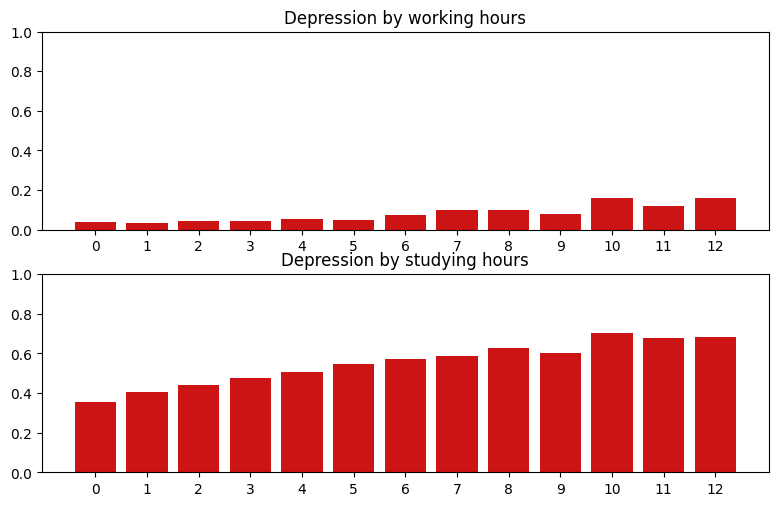

In [304]:
fig, ax = plt.subplots(nrows=2, figsize=(8, 5))
plt.tight_layout()

ax[0].bar(np.arange(13), working_professionals_dep_rate["dep_rate"], color="#cc1414")
ax[0].set_title("Depression by working hours")
ax[0].set_xticks(np.arange(13))
ax[0].set_ylim(0, 1)

ax[1].bar(np.arange(13), students_dep_rate["dep_rate"], color="#cc1414")
ax[1].set_title("Depression by studying hours")
ax[1].set_xticks(np.arange(13))
ax[1].set_ylim(0, 1)

plt.show()

# Financial Stress

In [313]:
financial_stress = data_train[["Financial Stress", "Depression", "id"]].groupby(["Financial Stress", "Depression"]).count()

financial_stress_dep = data_train[data_train["Depression"] == 1][["Financial Stress", "id"]].groupby(["Financial Stress"]).count()
financial_stress_non_dep = data_train[data_train["Depression"] == 0][["Financial Stress", "id"]].groupby(["Financial Stress"]).count()

financial_stress_dep_rate = pd.concat([financial_stress_dep, financial_stress_non_dep], axis=1)
financial_stress_dep_rate.columns = ["dep", "non_dep"]
financial_stress_dep_rate["dep_rate"] = financial_stress_dep_rate["dep"] / (financial_stress_dep_rate["dep"] + financial_stress_dep_rate["non_dep"])

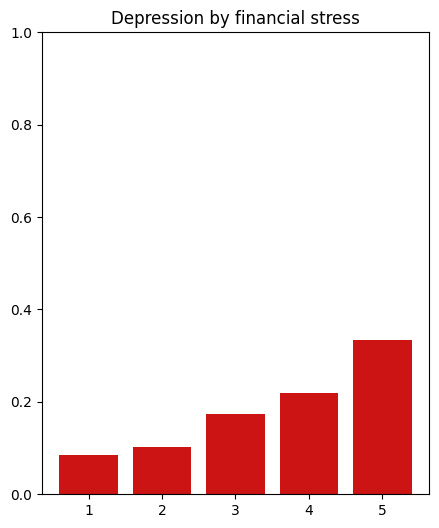

In [319]:
plt.figure(figsize=(5, 6))
plt.bar(np.arange(1, 6), financial_stress_dep_rate["dep_rate"], color="#cc1414")
plt.ylim(0, 1)
plt.title("Depression by financial stress")
plt.show()

# Family History of Mental Illness

In [331]:
family_hist_yes_dep = len(data_train[
    (data_train["Family History of Mental Illness"] == "Yes") &
    (data_train["Depression"] == 1)
])
family_hist_yes_non_dep = len(data_train[
    (data_train["Family History of Mental Illness"] == "Yes") &
    (data_train["Depression"] == 0)
])
family_hist_no_dep = len(data_train[
    (data_train["Family History of Mental Illness"] == "No") &
    (data_train["Depression"] == 1)
])
family_hist_no_non_dep = len(data_train[
    (data_train["Family History of Mental Illness"] == "No") &
    (data_train["Depression"] == 0)
])
family_hist_yes_dep_rate = family_hist_yes_dep / (family_hist_yes_dep + family_hist_yes_non_dep)
family_hist_no_dep_rate = family_hist_no_dep / (family_hist_no_dep + family_hist_no_non_dep)

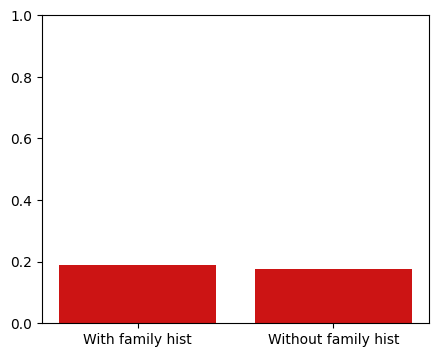

In [338]:
plt.figure(figsize=(5, 4))
plt.bar([0, 1], [family_hist_yes_dep_rate, family_hist_no_dep_rate], color="#cc1414")
plt.ylim(0, 1)
plt.xticks([0, 1], ["With family hist", "Without family hist"])
plt.show()

# Distributions

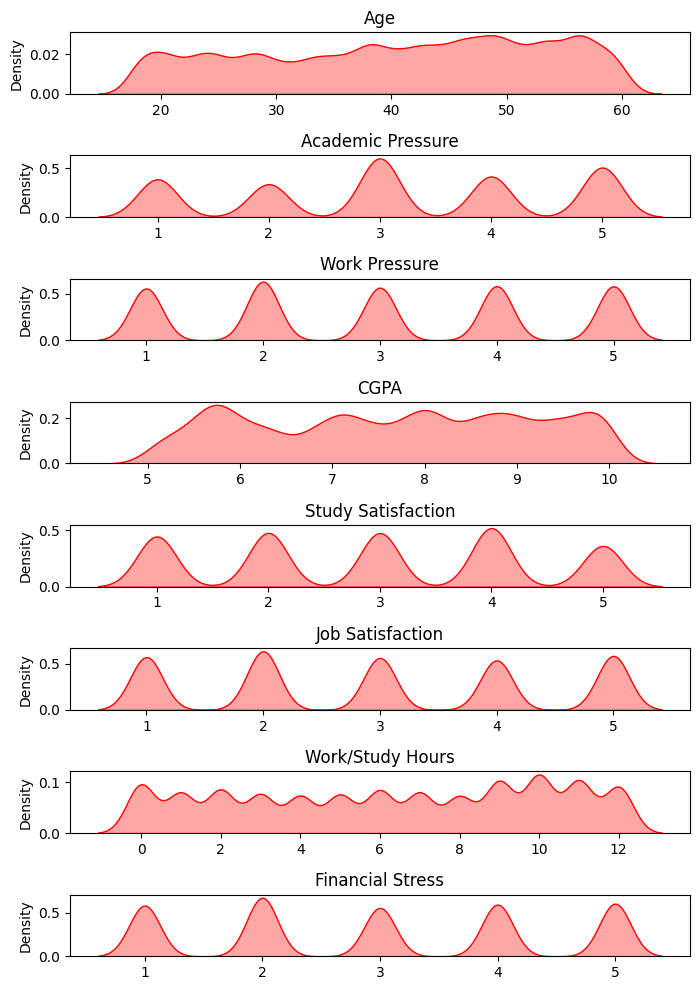

In [ ]:
cat_cols = list(data_train.select_dtypes(include=['object', 'category']).columns)
num_cols = [col for col in data_train.columns if col not in (cat_cols + ["id", "Depression"])]

fig, ax = plt.subplots(nrows=len(num_cols), figsize=(8, 1.5*len(num_cols)))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(num_cols):
    sns.kdeplot(ax=ax[i], data=data_train, x=col, color="red", fill=True, alpha=0.35)
    ax[i].set_title(col)
    ax[i].set_xlabel("")
plt.show()